# Supervised classification of SDSS sources with AstroPT

`astrospec.models.astropt.AstroPT`
([Smith et al. 2024, arXiv:2405.14930](https://arxiv.org/abs/2405.14930)) is
normally pretrained self-supervised first (`astropt_pretraining.ipynb`)
before a task head is attached, but there is no public spectra-pretrained
checkpoint to start from (`Smith42/astroPT`'s release is image-only). This
notebook instead trains AstroPT and a pooling head fully supervised, end to
end, on the same GALAXY / QSO / STAR classification task as
`galspecnet_source_classification_on_sdss.ipynb`, for a direct comparison
between a fixed-grid CNN and a wavelength-positioned transformer on
identical data.

The head is `astrospec.heads.CrossAttentionHead`: a learned query
cross-attends over AstroPT's token sequence, then an MLP maps the pooled
vector to class logits, the same head every sequence encoder in the
library composes with.

The data is the [MultimodalUniverse](https://huggingface.co/MultimodalUniverse)
SDSS release; `utils/sdss.py` needs `ASTROSPEC_SDSS_ROOT` set to a local
`healpix=*/` tree for the `CLASS` labels this notebook trains on, the Hub
copy does not carry them. Set it in a `.env` file in this directory (gitignored; see
`examples/README.md`). `utils/__init__.py` loads it automatically.

## Install example-only dependencies

Not part of AstroSpec's core install, only needed for this example.

In [1]:
!pip install -q h5py datasets scikit-learn matplotlib tqdm python-dotenv

## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import astrospec
from astrospec.data import Patchify
from astrospec.heads import CrossAttentionHead
from utils import sdss

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load a natural-proportion sample

6,000 spectra in whatever mix of GALAXY / QSO / STAR the survey actually
produces, exactly as `galspecnet_source_classification_on_sdss.ipynb` does,
so the two notebooks train and evaluate on the same data.

In [3]:
flux, labels = sdss.load_sample(n=6000)
flux = sdss.standardize(flux)
flux.shape, np.bincount(labels), sdss.CLASS_NAMES

((6000, 3841), array([4476,  444, 1080]), ['GALAXY', 'QSO', 'STAR'])

## Pixels to patches

AstroPT takes raw 32-pixel patches plus the wavelength of each patch's own
pixels, which its position embedding reads directly, unlike GalSpecNet,
which never sees `wavelength` at all and only knows a spectrum by which
pixel each feature falls on. `sdss.COMMON_GRID` is the same array for every
spectrum here, so it only needs patching once and broadcasts over the batch.

In [4]:
PATCH_SIZE = 32
patchify = Patchify(patch_size=PATCH_SIZE)

flux_patches, valid = patchify(torch.from_numpy(flux))
wavelength_patches, _ = patchify(torch.from_numpy(sdss.COMMON_GRID))
flux_patches.shape, wavelength_patches.shape, valid.shape

(torch.Size([6000, 121, 32]), torch.Size([121, 32]), torch.Size([6000, 121]))

## Split 70/10/20

Stratified, so each split keeps the same (imbalanced) class proportions, as
in the GalSpecNet notebook.

In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(labels))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=0)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.125, stratify=labels[train_idx], random_state=0
)

def loader(indices, shuffle):
    dataset = TensorDataset(
        flux_patches[indices], valid[indices], torch.from_numpy(labels[indices])
    )
    return DataLoader(dataset, batch_size=64, shuffle=shuffle)

train_loader, val_loader, test_loader = (
    loader(train_idx, True), loader(val_idx, False), loader(test_idx, False)
)
len(train_idx), len(val_idx), len(test_idx)

(4200, 600, 1200)

## The model

AstroPT's registry defaults match the OmniSpectrum training configuration
(8 layers, width 512), verified against its released checkpoint's shapes in
the project's own checkpoint audit. Only the architecture is reused here,
not any weights, since none exist for spectra. `CrossAttentionHead` pools
the token sequence before the classification MLP; `key_padding_mask` is
`nn.MultiheadAttention`'s own convention, the inverse of the `valid` flag
`Patchify` returns.

In [6]:
class AstroPTClassifier(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, flux, wavelength, valid):
        features = self.encoder.forward_features(flux, wavelength, valid=valid)
        return self.head(features, key_padding_mask=~valid)


encoder = astrospec.create_model("astropt", input_dim=PATCH_SIZE)
head = CrossAttentionHead(embed_dim=encoder.embed_dim, num_outputs=len(sdss.CLASS_NAMES))
model = AstroPTClassifier(encoder, head).to(device)
wavelength_patches = wavelength_patches.to(device).unsqueeze(0)
sum(p.numel() for p in model.parameters())

30097411

## Train

Class weights come from the training split's own label counts (inverse
frequency, mean-normalized), exactly as in the GalSpecNet notebook, so the
rare QSO class costs more per mistake than GALAXY.

In [7]:
EPOCHS = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

class_counts = np.bincount(labels[train_idx], minlength=len(sdss.CLASS_NAMES))
class_weight = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weight = (class_weight / class_weight.mean()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight)

def evaluate(data_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, v, y in data_loader:
            wavelength = wavelength_patches.expand(len(x), -1, -1)
            pred = model(x.to(device), wavelength, v.to(device)).argmax(-1).cpu()
            correct += (pred == y).sum().item()
            total += len(y)
    return correct / total

epoch_bar = tqdm(range(EPOCHS), desc="training")
for epoch in epoch_bar:
    model.train()
    running = 0.0
    for x, v, y in train_loader:
        wavelength = wavelength_patches.expand(len(x), -1, -1)
        optimizer.zero_grad()
        loss = criterion(model(x.to(device), wavelength, v.to(device)), y.to(device))
        loss.backward()
        optimizer.step()
        running += loss.item() * len(y)
    epoch_bar.set_postfix(
        train_loss=f"{running / len(train_idx):.4f}",
        val_acc=f"{evaluate(val_loader):.4f}",
    )

training:   0%|          | 0/10 [00:00<?, ?it/s]

training:   0%|          | 0/10 [00:11<?, ?it/s, train_loss=0.7590, val_acc=0.7950]

training:  10%|█         | 1/10 [00:11<01:44, 11.65s/it, train_loss=0.7590, val_acc=0.7950]

training:  10%|█         | 1/10 [00:22<01:44, 11.65s/it, train_loss=0.5888, val_acc=0.8067]

training:  20%|██        | 2/10 [00:22<01:29, 11.16s/it, train_loss=0.5888, val_acc=0.8067]

...

training:  80%|████████  | 8/10 [01:42<00:22, 11.48s/it, train_loss=0.1860, val_acc=0.8733]

training:  90%|█████████ | 9/10 [01:42<00:11, 11.44s/it, train_loss=0.1860, val_acc=0.8733]

training:  90%|█████████ | 9/10 [01:54<00:11, 11.44s/it, train_loss=0.1885, val_acc=0.9050]

training: 100%|██████████| 10/10 [01:54<00:00, 11.49s/it, train_loss=0.1885, val_acc=0.9050]

training: 100%|██████████| 10/10 [01:54<00:00, 11.41s/it, train_loss=0.1885, val_acc=0.9050]

## Test accuracy and confusion matrix

              precision    recall  f1-score   support

      GALAXY      0.959     0.916     0.937       895
         QSO      0.491     0.921     0.641        89
        STAR      0.949     0.782     0.858       216

    accuracy                          0.892      1200
   macro avg      0.800     0.873     0.812      1200
weighted avg      0.923     0.892     0.901      1200



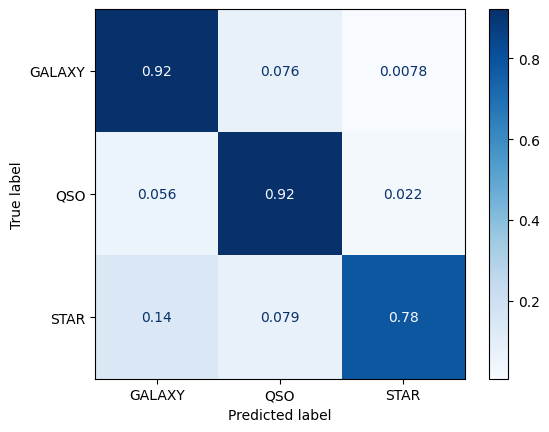

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

model.eval()
preds = []
with torch.no_grad():
    for x, v, _ in test_loader:
        wavelength = wavelength_patches.expand(len(x), -1, -1)
        preds.append(model(x.to(device), wavelength, v.to(device)).argmax(-1).cpu())
preds = torch.cat(preds).numpy()

print(classification_report(labels[test_idx], preds, target_names=sdss.CLASS_NAMES, digits=3))
ConfusionMatrixDisplay.from_predictions(
    labels[test_idx], preds, display_labels=sdss.CLASS_NAMES, normalize="true", cmap="Blues"
)

## Notes

Same tutorial scale as the GalSpecNet notebook: 6,000 spectra, one
sub-survey, 10 epochs, so treat the numbers as a sanity check on the wiring
rather than a benchmark. `galspecnet_source_classification_on_sdss.ipynb`'s
own notes point at QSO as the weak class for a fixed-grid CNN, since
emission lines that identify a quasar land on a different pixel at every
redshift while a star's features stay put; compare that notebook's
per-class report and confusion matrix against this one's to see whether
reading position from `wavelength` actually helps.

This is also not what AstroPT is for. Its own objective is self-supervised
pretraining (`astropt_pretraining.ipynb`), meant to produce a
representation that a small head fine-tunes cheaply on many tasks; training
the full 28.5M-parameter encoder from a random init on 4,200 labelled
spectra, as this notebook does, is a much less data-efficient use of it.